In [46]:
import pandas as pd 

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim 


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt 

# Data Preparation

In [33]:
df_flux_data = pd.read_csv("../data/processed/clean_flux.csv")

X = df_flux_data.drop(columns=['id', 'class']).values 
y = df_flux_data['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.22, random_state=42, stratify=y)

# Standard Scaler 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Reshape from [batch, length] to [batch, 1, length]
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)

print(f"X_train shape: {X_train_tensor.shape}")

# Create DataLoader for Batching 
batch_size = 64 

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset6 = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset6, batch_size=batch_size, shuffle=False)

X_train shape: torch.Size([4601, 1, 4608])


# Model Architectures

## Model v1

In [13]:
class Exoplanet1DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1: Find base patterns 
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # Block 2: Find more complex petterns 
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=4, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        # Block 3: Classifier: We make a decision based on the patterns found\
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*1152, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        x = self.flatten(x)

        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))

        return x 


In [14]:
model_0 = Exoplanet1DCNN()
dummy_input = torch.randn(64, 1, 4608)
output = model_0(dummy_input)

print(f"Model architecture is ready. Output shape: {output.shape}") 

Model architecture is ready. Output shape: torch.Size([64, 1])


## Model v2

In [37]:
class Exoplanet1DCNN_v2(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1: Find base patterns 
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16) 
        self.pool1 = nn.MaxPool1d(2)
        
        # Block 2: Find more complex petterns
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        
        # Block 3: Classifier: We make a decision based on the patterns found\
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(32 * 1152, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Conv -> BatchNorm -> ReLU -> MaxPool
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        
        x = self.flatten(x)
        
        x = self.dropout(torch.relu(self.bn3(self.fc1(x))))
        x = self.sigmoid(self.fc2(x))
        return x
    
model_0 = Exoplanet1DCNN()
dummy_input = torch.randn(64, 1, 4608)
output = model_0(dummy_input)

print(f"Model architecture is ready. Output shape: {output.shape}")

Model architecture is ready. Output shape: torch.Size([64, 1])


## Model v3

In [41]:
class Exoplanet1DCNN_v3(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Increasing the kernel_size to 21 (Wide Receptive Field)
        self.conv1 = nn.Conv1d(1, 16, kernel_size=21, padding=10)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(16, 32, kernel_size=21, padding=10)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        
        self.flatten = nn.Flatten()
        
        # Dimension after two MaxPool1d(2): 4608 -> 2304 -> 1152
        self.fc1 = nn.Linear(32 * 1152, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout(torch.relu(self.bn3(self.fc1(x))))
        x = self.sigmoid(self.fc2(x))
        return x

# Training Loop

## Model v1

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_1 = Exoplanet1DCNN().to(device)

# Binary Cross Entropy Loss 
criterion = nn.BCELoss()

optimizer_1 = optim.Adam(model_1.parameters(), lr=0.001)
epochs = 30

for epoch in range(epochs):
    model_1.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).view(-1, 1)

        # Forward pass 
        outputs = model_1(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer_1.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epochs {epoch+1}/{epochs} - Loss: {avg_loss}")

print("Training Finished ")

Device: cuda
Epochs 1/30 - Loss: 0.6929081173406707
Epochs 2/30 - Loss: 0.6944799853695763
Epochs 3/30 - Loss: 0.6935281140936745
Epochs 4/30 - Loss: 0.6942045763134956
Epochs 5/30 - Loss: 0.6936325058341026
Epochs 6/30 - Loss: 0.6950418709052933
Epochs 7/30 - Loss: 0.693028604818715
Epochs 8/30 - Loss: 0.6933174621727731
Epochs 9/30 - Loss: 0.6933546629216936
Epochs 10/30 - Loss: 0.6951157127817472
Epochs 11/30 - Loss: 0.6945896330806944
Epochs 12/30 - Loss: 0.693612222870191
Epochs 13/30 - Loss: 0.6930245674318738
Epochs 14/30 - Loss: 0.693415544099278
Epochs 15/30 - Loss: 0.694197780556149
Epochs 16/30 - Loss: 0.6934863726298014
Epochs 17/30 - Loss: 0.6935819445384873
Epochs 18/30 - Loss: 0.6934993921054734
Epochs 19/30 - Loss: 0.6941141055689918
Epochs 20/30 - Loss: 0.6939867527948486
Epochs 21/30 - Loss: 0.6938907595144378
Epochs 22/30 - Loss: 0.6924954313370917
Epochs 23/30 - Loss: 0.6936636914809545
Epochs 24/30 - Loss: 0.6937869704431958
Epochs 25/30 - Loss: 0.6939094629552629


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Evaluating 1D-CNN on Test Data...

Deep Learning (1D-CNN) Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      1.00      0.67       660
         1.0       0.00      0.00      0.00       638

    accuracy                           0.51      1298
   macro avg       0.25      0.50      0.34      1298
weighted avg       0.26      0.51      0.34      1298



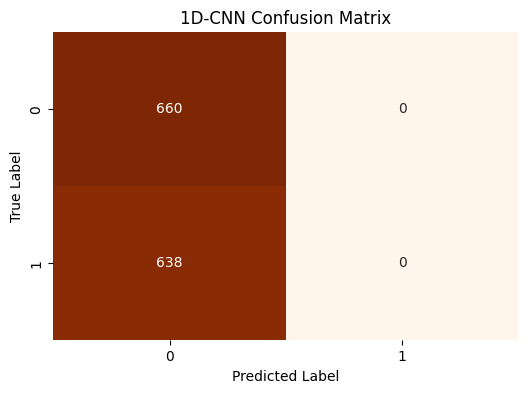

In [ ]:
model_1.eval()

all_preds = []
all_targets = []

print("Evaluating 1D-CNN on Test Data...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model_1(batch_X)
        
        preds = (outputs >= 0.5).float().cpu().numpy()
        targets = batch_y.numpy()
        
        all_preds.extend(preds)
        all_targets.extend(targets)

print("\nDeep Learning (1D-CNN) Classification Report:")
print(classification_report(all_targets, all_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("1D-CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Model v2

In [38]:
model_2 = Exoplanet1DCNN_v2().to(device)
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.0005)

In [39]:
# Binary Cross Entropy Loss 
criterion = nn.BCELoss()

epochs = 30

for epoch in range(epochs):
    model_2.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).view(-1, 1)

        # Forward pass 
        outputs = model_2(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer_2.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epochs {epoch+1}/{epochs} - Loss: {avg_loss}")

print("Training Finished ")

Epochs 1/30 - Loss: 0.7125638814436065
Epochs 2/30 - Loss: 0.7107457659310765
Epochs 3/30 - Loss: 0.7184528236587843
Epochs 4/30 - Loss: 0.7166319953070747
Epochs 5/30 - Loss: 0.7125283463133706
Epochs 6/30 - Loss: 0.7144152364797063
Epochs 7/30 - Loss: 0.7169880858725972
Epochs 8/30 - Loss: 0.713422053390079
Epochs 9/30 - Loss: 0.718486390180058
Epochs 10/30 - Loss: 0.7195890231264962
Epochs 11/30 - Loss: 0.7147655420833163
Epochs 12/30 - Loss: 0.7161132386989064
Epochs 13/30 - Loss: 0.711930481923951
Epochs 14/30 - Loss: 0.7099722201625506
Epochs 15/30 - Loss: 0.7143413490719266
Epochs 16/30 - Loss: 0.7152079070607821
Epochs 17/30 - Loss: 0.718398799498876
Epochs 18/30 - Loss: 0.7186863736973869
Epochs 19/30 - Loss: 0.7180077773001459
Epochs 20/30 - Loss: 0.7199083657728301
Epochs 21/30 - Loss: 0.7192912896474203
Epochs 22/30 - Loss: 0.7188865608639188
Epochs 23/30 - Loss: 0.713377551900016
Epochs 24/30 - Loss: 0.717712878353066
Epochs 25/30 - Loss: 0.7181702992982335
Epochs 26/30 - 

Evaluating 1D-CNN on Test Data...

Deep Learning (1D-CNN) Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.15      0.26       660
         1.0       0.52      0.97      0.68       638

    accuracy                           0.55      1298
   macro avg       0.68      0.56      0.47      1298
weighted avg       0.68      0.55      0.46      1298



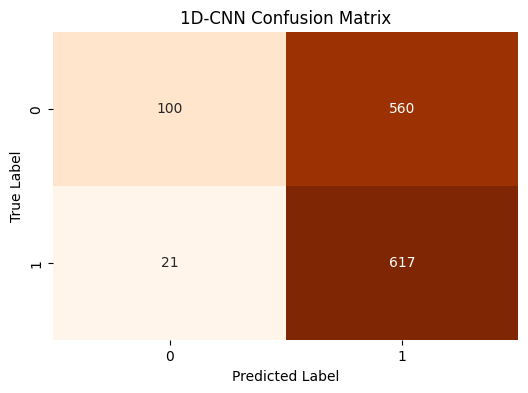

In [40]:
model_2.eval()

all_preds = []
all_targets = []

print("Evaluating 1D-CNN on Test Data...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model_2(batch_X)
        
        preds = (outputs >= 0.5).float().cpu().numpy()
        targets = batch_y.numpy()
        
        all_preds.extend(preds)
        all_targets.extend(targets)

print("\nDeep Learning (1D-CNN) Classification Report:")
print(classification_report(all_targets, all_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("1D-CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## model v3

In [42]:
model_3 = Exoplanet1DCNN_v3().to(device)
optimizer_3 = optim.Adam(model_3.parameters(), lr=0.0005)

In [43]:
# Binary Cross Entropy Loss 
criterion = nn.BCELoss()

epochs = 30

for epoch in range(epochs):
    model_3.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).view(-1, 1)

        # Forward pass 
        outputs = model_3(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer_3.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epochs {epoch+1}/{epochs} - Loss: {avg_loss}")

print("Training Finished ")

Epochs 1/30 - Loss: 0.7068303856584761
Epochs 2/30 - Loss: 0.715823528667291
Epochs 3/30 - Loss: 0.713003927634822
Epochs 4/30 - Loss: 0.7195625454187393
Epochs 5/30 - Loss: 0.721087215675248
Epochs 6/30 - Loss: 0.710594031545851
Epochs 7/30 - Loss: 0.7132359387146102
Epochs 8/30 - Loss: 0.7150245308876038
Epochs 9/30 - Loss: 0.7162453391485744
Epochs 10/30 - Loss: 0.7062183933125602
Epochs 11/30 - Loss: 0.7147878284255663
Epochs 12/30 - Loss: 0.7152815187970797
Epochs 13/30 - Loss: 0.7115359215272797
Epochs 14/30 - Loss: 0.7181421394149462
Epochs 15/30 - Loss: 0.718962501320574
Epochs 16/30 - Loss: 0.713312580353684
Epochs 17/30 - Loss: 0.7135403619872199
Epochs 18/30 - Loss: 0.7085436441832118
Epochs 19/30 - Loss: 0.7169548902246687
Epochs 20/30 - Loss: 0.7165445817841424
Epochs 21/30 - Loss: 0.709884432454904
Epochs 22/30 - Loss: 0.7171711060735915
Epochs 23/30 - Loss: 0.7141107991337776
Epochs 24/30 - Loss: 0.707165421711074
Epochs 25/30 - Loss: 0.712841395702627
Epochs 26/30 - Los

Evaluating 1D-CNN on Test Data...

Deep Learning (1D-CNN) Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.13      0.22       660
         1.0       0.51      0.94      0.66       638

    accuracy                           0.53      1298
   macro avg       0.59      0.53      0.44      1298
weighted avg       0.59      0.53      0.43      1298



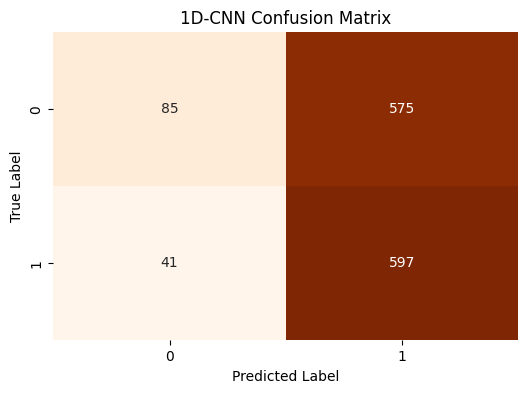

In [44]:
model_3.eval()

all_preds = []
all_targets = []

print("Evaluating 1D-CNN on Test Data...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model_3(batch_X)
        
        preds = (outputs >= 0.5).float().cpu().numpy()
        targets = batch_y.numpy()
        
        all_preds.extend(preds)
        all_targets.extend(targets)

print("\nDeep Learning (1D-CNN) Classification Report:")
print(classification_report(all_targets, all_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("1D-CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Model Comparison Plot 

Loading Random Forest model and data...
Extracting probabilities from 1D-CNN...


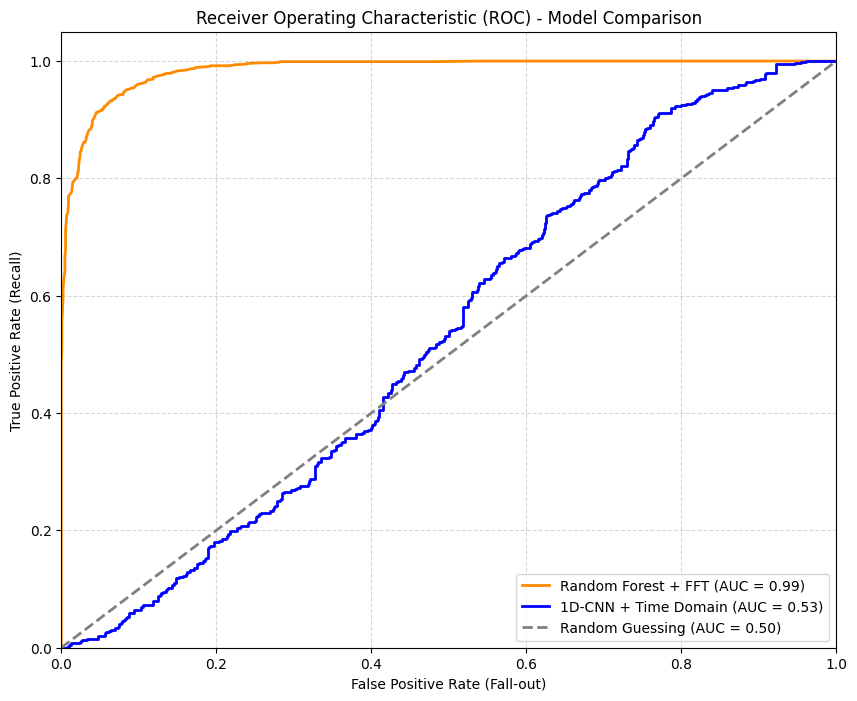

In [ ]:
import joblib

# ==========================================
# 1. Random Forest Preparation (Baseline)
# ==========================================
print("Loading Random Forest model and data...")
# Loading the saved model
rf_model = joblib.load('../models/rf_baseline.pkl')

# Uploading features for classic ML
features_df = pd.read_csv('../data/processed/clean_features.csv')
fft_df = pd.read_csv('../data/processed/fft_features.csv')
df_merged = pd.merge(features_df, fft_df, on=['id', 'class'])

X_rf = df_merged.drop(columns=['id', 'class'])
y_rf = df_merged['class']

# Do the same split so that the tests are fair.
_, X_test_rf, _, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

# Get probabilities from Random Forest (we take column [:, 1] for class 1)
rf_probs = rf_model.predict_proba(X_test_rf)[:, 1]


# ==========================================
# 2. Подготовка 1D-CNN (Deep Learning)
# ==========================================
print("Extracting probabilities from 1D-CNN...")
model.eval() # Making sure that the network is in inference mode
cnn_probs = []
cnn_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        # Get raw probabilities (from 0 to 1) from the Sigmoid layer
        probs = model(batch_X).cpu().numpy().flatten()
        targets = batch_y.numpy().flatten()
        
        cnn_probs.extend(probs)
        cnn_targets.extend(targets)


# ==========================================
# 3. Calculating metrics for ROC-AUC
# ==========================================
rf_fpr, rf_tpr, _ = roc_curve(y_test_rf, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

cnn_fpr, cnn_tpr, _ = roc_curve(cnn_targets, cnn_probs)
cnn_auc = auc(cnn_fpr, cnn_tpr)


# ==========================================
# 4. Visualization of the Model Comparison
# ==========================================
plt.figure(figsize=(10, 8))
plt.plot(rf_fpr, rf_tpr, color='darkorange', lw=2, label=f'Random Forest + FFT (AUC = {rf_auc:.2f})')
plt.plot(cnn_fpr, cnn_tpr, color='blue', lw=2, label=f'1D-CNN + Time Domain (AUC = {cnn_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-out)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) - Model Comparison')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()